# Exploring The CanSWE Dataset With Python

CanSWE is a dataset that includes Pan-Canadian observations of snow water equivalent (SWE). This data is collected from sites across Canada by national, provicial and territorial agencies as well as academic institutions, hydropower companies and their partners. Each site also has a SWE measurement method that describes how the data was sampled, and these measurements follow the World Meteorological Organization (WMO) standards. Snow Water Equivalent is ultimately an important variable because it provides us with an understanding of how much water is available in a given amount of snow, allowing us to plan for how to use our scarce water resources.  <br> <br>

Even though this dataset contains point observations on SWE, snow depth and snowpack bulk density, we will primarily focus on analyzing the SWE data because SWE is much more accurate in determining how much water is available in a snowpack compared to other measurements such as snow depth. During a storm, one inch of rain can produce between 2 to over 50 inches of snow depending on the air temperature. Storms that occur in colder air temperatures tend to create a large quantity snow that is dry and powdery while storms that occur in warmer air temperatures tend to create a smaller quantity snow that is mostly sleet, which definetely much less dry and powdery. Since we have storms that occur during varying temperatures throughout the winter, we cannot directly convert snow depth to the cumulative amount of water that is available in a given amount of snow. <br> <br>

The goal of this tutorial is to analyze how snow water equivalent changes over time in different regions across Canada. Nonetheless, we will also explore how snow depth and snowpack bulk density evolve over time in some locations as well. For more information or to view the complete dataset, please refer to: https://zenodo.org/records/10835278. <br> <br>

## Requirements
First, we import all necessary Python libraries. Some of these are standard Python libraries, while others are third-party libraries that must first be installed in your Python environment.

In [107]:
# Date libraries
import datetime
from datetime import datetime, timedelta, date

# Data libraries
import numpy as np
import pandas as pd

# Plotting libraries
import matplotlib.pyplot as plt 
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.path import Path
import matplotlib.colors as mcolors
from matplotlib import cm
import matplotlib as mpl

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.feature as cf

import seaborn as sns

## Viewing The Raw Data

The CanSWE database is available in both csv and netCDF formats. In this tutorial, we will work with the csv format file. To begin, we will read the CanSWE dataset into a pandas dataframe using the `read_csv()` function. 

The CanSWE csv file is large and contains a variety of data, so we will need to pass two arguments to the `read_csv()` to instruct pandas on how to interpret the data. First, we set the `low_memory` argument to `False`. This will prompt pandas to read the whole file into memory at once, rather than reading the data in chunks, which should prevent pandas from assigning inconsistent data types in a given column. Once this step is completed, we will display the first 6 rows of the data using the `head(n)` command where n is an integer representing the first 'n' number of rows that should be printed.

In [108]:
df = pd.read_csv(
    'CanSWE-CanEEN_1928-2023_v6.csv', 
    low_memory = False,
 )

df.head(6)

,station_id,time,lat,lon,elevation,source,station_name,station_name_sec,station_name_ter,station_id_sec,station_id_ter,type_mes,snw,snd,den,data_flag_snw,data_flag_snd,qc_flag_snw,qc_flag_snd
0,ALE-05AA805,1965-04-06,49.266666,-114.35,1525.0,Alberta Environment,WEST CASTLE SNOW,WEST CASTLE,WEST CASTLE OPEN,SCD-AL219,SCD-AL221,0,688.0,1.76,390.90910,b'',b'',b'',b''
1,ALE-05AA805,1968-03-06,49.266666,-114.35,1525.0,Alberta Environment,WEST CASTLE SNOW,WEST CASTLE,WEST CASTLE OPEN,SCD-AL219,SCD-AL221,0,155.0,0.36,430.55554,b'',b'',b'',b''
2,ALE-05AA805,1968-04-03,49.266666,-114.35,1525.0,Alberta Environment,WEST CASTLE SNOW,WEST CASTLE,WEST CASTLE OPEN,SCD-AL219,SCD-AL221,0,269.0,0.59,455.93220,b'',b'',b'',b''
3,ALE-05AA805,1969-04-01,49.266666,-114.35,1525.0,Alberta Environment,WEST CASTLE SNOW,WEST CASTLE,WEST CASTLE OPEN,SCD-AL219,SCD-AL221,0,378.0,0.98,385.71430,b'',b'',b'',b''
4,ALE-05AA805,1970-04-02,49.266666,-114.35,1525.0,Alberta Environment,WEST CASTLE SNOW,WEST CASTLE,WEST CASTLE OPEN,SCD-AL219,SCD-AL221,0,335.0,0.98,341.83673,b'',b'',b'',b''
5,ALE-05AA805,1971-04-06,49.266666,-114.35,1525.0,Alberta Environment,WEST CASTLE SNOW,WEST CASTLE,WEST CASTLE OPEN,SCD-AL219,SCD-AL221,0,356.0,0.91,391.20880,b'',b'',b'',b''


Looking at the first few lines of data above and scrolling across the columns, we can see that the file contains point observations of snow water equivalent ($kg/m^2$), snow depth (m), and snowpack bulk density ($kg/m^3$). Snow water equivalent is defined as the amount of water present within a snowpack. Snow depth is defined as the cumulative amount of snow on the ground. Snowpack bulk density is defined as how closely packed the snow particles are. <br> <br> 

The first several columns contain information about where and when the observations were collected by providing the station identification code, station name, station elevation, station latitude/longitude, and  the dates and times when the observations were made. The quality control flags, which are outlined in the 4 rightmost columns of this SWE dataset, are indicators about the quality of snow water equivalent and snow depth data. <br> <br>

If there are no quality flags, the data is of the highest quality. However, flagged data suggests that the data is of lesser quality because there could have been sampling problems, precise sampling could have been unavailable or sampling could have been conducted outside of the normal sampling period. Flagged data could also mean that some data entries are missing, revised, or just estimates.

Next, we can create a map to display the locations of all the stations included in the CanSWE dataset. We will create similar maps below in this tutorial, so we will first create a map function that will allow us to reuse this code.

#### Code For Creating a Contour Plot
Below is a Python function called `create_map_plot()` that uses the Matplotlib and Cartopy libraries to create a contour plot, which helps us visualize the geographical locations of various stations.

In [109]:
def create_map_plot(map, set_extent, x_interval, y_interval, provincial_borders,
                    singular_color, title, width = 11, height = 7):

    '''
    Create contour plot to visualize geographical locations of various stations
    
    Parameters
    ----------
    map : pandas dataframe
        dataframe containing information on station ID, longitude, and latitude for plotting purposes
    set_extent: tuple
        (x0, x1, y0, y1) coordinates of the contour map
    x_interval: integer
        longitude coordinate interval
    y_interval: integer
        latitude coordinate interval
    provincial_borders: boolean
        whether the contour plot should have provincial borders
    singular_color: boolean
        whetehr the stations should have the same color or varying colours from a colour palette
    width: integer
        width of the contour plot
    height: integer
        height of the contour plot
    '''

    figure = plt.figure(figsize = (width, height))
    ax = figure.add_subplot(1, 1, 1, projection = ccrs.PlateCarree()) 
    ax.set_title(title)
    ax.set_extent([set_extent[0], set_extent[1], set_extent[2], set_extent[3]])
    ax.coastlines()
    plt.xticks(range(set_extent[0] + 1, set_extent[1] + 1, x_interval), 
               range(set_extent[0] + 1, set_extent[1] + 1, x_interval), fontsize = 8) 
    plt.yticks(range(set_extent[2], set_extent[3], y_interval), 
               range(set_extent[2], set_extent[3], y_interval), fontsize = 8)

    states_provinces = cfeature.NaturalEarthFeature(
        category ='cultural',
        name ='admin_1_states_provinces_lines',
        scale ='10m',
        edgecolor='black',
        facecolor = 'none')
    if provincial_borders:
        ax.add_feature(states_provinces, linestyle = '--', linewidth = 0.7, zorder = 0.1)

    countries = cfeature.NaturalEarthFeature(
        category = 'cultural',
        name = 'admin_0_boundary_lines_land',
        scale = '10m',
        edgecolor='black',
        facecolor = 'none')
    ax.add_feature(countries, linestyle = '--', linewidth = 0.7, zorder = 0.1)

    oceans = cfeature.NaturalEarthFeature(
        'physical', 
        'ocean', 
        scale = '10m',
        facecolor = cfeature.COLORS['water'],
        zorder=-1)
    ax.add_feature(oceans)

    land = cfeature.NaturalEarthFeature(
        'physical', 
        'land', 
        scale = '10m',
        facecolor = cfeature.COLORS['land'], 
        zorder=-1) 
    ax.add_feature(land, facecolor = 'beige') 

    if singular_color:
        ax.scatter(map['lon'], map['lat'], c = ['#FF6865'], edgecolor = 'black', linewidths = 0.5,
                   s = 30, marker = 'o', linestyle = '')
    else:
        #c = sns.color_palette("coolwarm_r", map['lon'].size).as_hex()
        ax.scatter(map['lon'], map['lat'], c= map['snw'], cmap = 'bwr_r',
            edgecolor = 'black', linewidths = 0.5, s = 30, marker = 'o', linestyle='')
        norm = mpl.colors.Normalize(vmin = min(map['snw']), vmax = max(map['snw']))
        figure.colorbar(mpl.cm.ScalarMappable(norm = norm, cmap = 'bwr_r'), extend = 'max',
             ax=ax, fraction = 0.02, orientation = 'vertical', label= 'Snow Water Equivalent ($kg/m^2$)')
        # cbar = figure.colorbar(cm.ScalarMappable(cmap = "coolwarm_r"), ax = ax, ticks = [0, 0.5, 1], orientation = 'verical')
        # cbar.ax.set_xticklabels(['Low Maximum SWE', 'Medium Maximum SWE', 'High Maximum SWE'])
    for index, row in map.iterrows():
        ax.text(row['xlabel'], row['ylabel'], row['station_id'], fontsize = 8)
    
    plt.show()

#### Contour Map of all Sites
From the contour map below, we can see there are stations all over Canada. Furthermore, there are a few stations in Asia, where the data is sampled by Rio Tinto Alcan - a Canada based mining company headquartered in Montreal, Quebec. However, for this tutorial, we will just focus on the stations that are located in Canada.

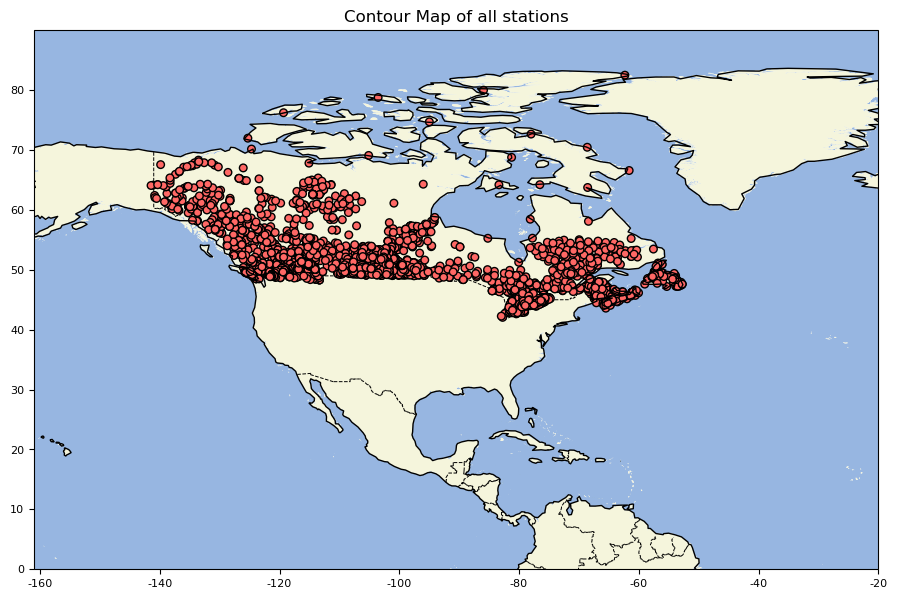

In [110]:
map = pd.DataFrame()
map['lon'] = df.groupby('station_id').first()['lon']
map['lat'] = df.groupby('station_id').first()['lat']
map['station_id'] = np.repeat('', map['lon'].size)
map['xlabel'] = np.repeat(np.nan, map['lon'].size)
map['ylabel'] = np.repeat(np.nan, map['lon'].size)
create_map_plot(map, (-161, -20, 0, 90), 20, 10, False, True, 'Contour Map of all stations')

## Finding The Station With The Most Entries
In this CanSWE dataset, the station with the most data entries is station BCE-2G03P. <br>
Let's take a closer look at station BCE-2G03P (Blackwall Peak-Pillow). 

In [111]:
stn = 'BCE-2G03P'
longitude = -120.7725
latitude = 49.09414
# Station BCE-2G03P
# Finding where the Station BCE-2G03P data is
i = -1
count = 0
for index, row in df.iterrows():
    if row['station_id'] == 'BCE-2G03P':
        i = index
        break

for index, row in df.iterrows():
    if row['station_id'] == 'BCE-2G03P':
        count = count + 1

df.loc[(df['station_id'] == 'BCE-2G03P')].iloc[[0], [0, 2, 3, 4, 6]]


,station_id,lat,lon,elevation,station_name
721113,BCE-2G03P,49.09414,-120.7725,1940.0,BLACKWALL PEAK-PILLOW


This station is located in southern British Columbia. It has a latitude of 49.454445 (degrees North) and a longitude of -123.031944 (degrees East) and the station elevation is 1940 meters. We'll start by plotting the location of this station on a map. We can call our `create_map_plot()` function to plot the location of Station BCE-2G03P.

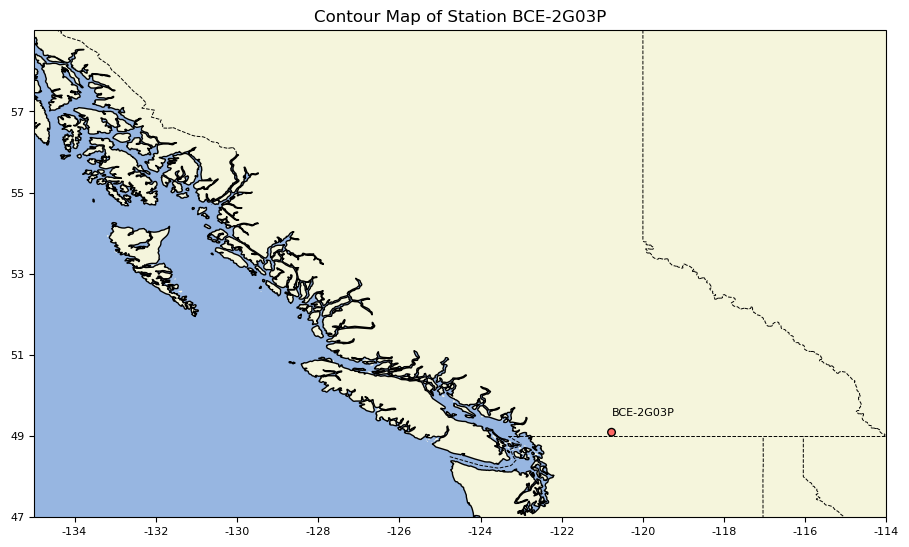

In [112]:
map = pd.DataFrame(columns = ['lon', 'lat', 'station_id', 'xlabel', 'ylabel'])
map.loc[0] = ({'lon': longitude, 'lat': latitude, 'station_id': stn, 'xlabel': longitude, 'ylabel': latitude + 0.4})
create_map_plot(map, (-135, -114, 47, 59), 2, 2, True, True, 'Contour Map of Station '+stn)

Note: We get a download warning for the first time we create a map

## Visualizing CanSWE Data From a Single Station

After plotting the geographical location of Station BCE-2G03P, the next step is to extract this station's SWE, snow depth, and snowpack bulk density data because we would like to see how these measurements evolve over time at this location.

In [113]:
# Locating indices to determine where the station BCE-2G03P data is
begin = i
end = begin + count - 1

# Creating a dataframe with just station BCE-2G03P data
reduced_Df = df.loc[begin:end]

#### Code For Creating a Times Series Graph
Below is a Python function called `create_time_series()` that uses the Matplotlib library to create a time series graph, which helps us visualize trends in snow water equivalent, snow depth and snowpack bulk density.

In [114]:
def create_time_series(time_series, data, label, title, xaxis, yaxis, begin, end, legend_present, width = 11, height = 4.8):
    '''
    Create time series to visualize trends in snow water equivalent, snow depth and snowpack bulk density
    
    Parameters
    ----------
    x : list of pandas dataframes
        sampling data for each site
    data : string
        type of data (either snow water equivalent, snow depth or snowpack bulk density)
    label: list of strings
        station IDs
    title: string
        title of the plot
    xaxis: string
        xaxis label of the plot
    yaxis: string
        yaxis label of the plot
    begin: datetime object
        lower xaxis limit
    end: datetime object
        upper xaxis limit
    legend_present: boolean
        whether a legend is needed in the plot
    width: integer
        width of the time series graph
    height: integer
        height of the time series graph
    '''
    figure, ax = plt.subplots(figsize=(width, height))
    ax.set_title(title)
    ax.set_xlabel(xaxis)
    ax.set_ylabel(yaxis)
    ax.set_xlim(begin, end)
    if data == 'snw':
        for i in range(0, len(time_series)):
            ax.scatter(time_series[i]['time'], time_series[i]['snw'], s = 2, label = label[i])
    elif data == 'snd':
        for i in range(0, len(time_series)):
            ax.scatter(time_series[i]['time'], time_series[i]['snd'], s = 2, label = label[i])
    elif data == 'den':
        for i in range(0, len(time_series)):
            ax.scatter(time_series[i]['time'], time_series[i]['den'], s = 2, label = label[i])
    if legend_present:
        ax.legend()
    plt.show()

#### Plotting The Snow Water Equivalent Data For Station BCE-2G03P
We now use the `create_time_series()` function to plot the snow water equivalent data for this station.

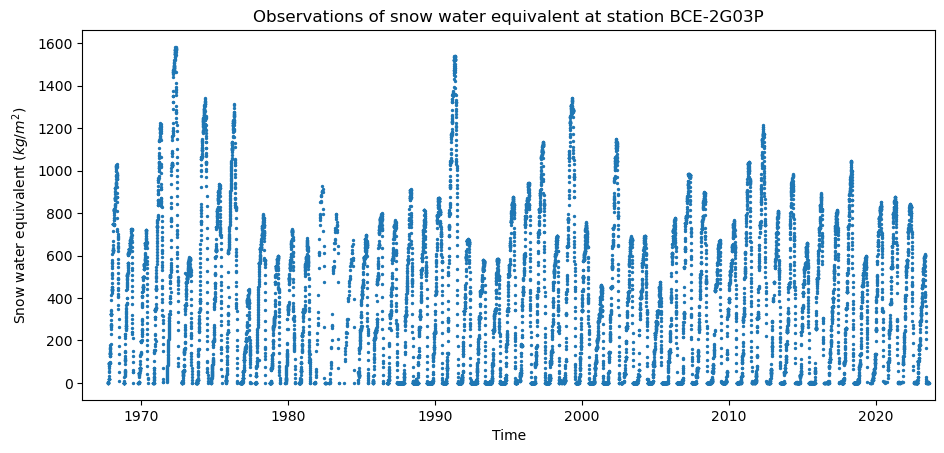

In [115]:
# I made some minor edits to the title, let's change the rest of the plot titles to match
title = 'Observations of snow water equivalent at station '+stn 
xaxis = 'Time'
yaxis = 'Snow water equivalent ($kg/m^2$)' # let's change this to (kg m-2) where the -2 is a superscript

create_time_series([reduced_Df], 'snw', [stn], title, xaxis, yaxis, 
                   datetime(1966, 1, 1).date(), datetime(2024, 1, 1), False)

The maximum snow water equivalent is 1582.4 $kg/m^2$ on April 28, 1972. The minimum snow water equivalent is 0  $kg/m^2$ when there is no snow, which is usually from late May to early November. The average snow water equivalent is approximately 381.2 $kg/m^2$.

#### Plotting The Snow Depth Data For Station BCE-2G03P
Secondly, we use the `create_time_series()` function to plot the snow depth data for Station BCE-2G03P.

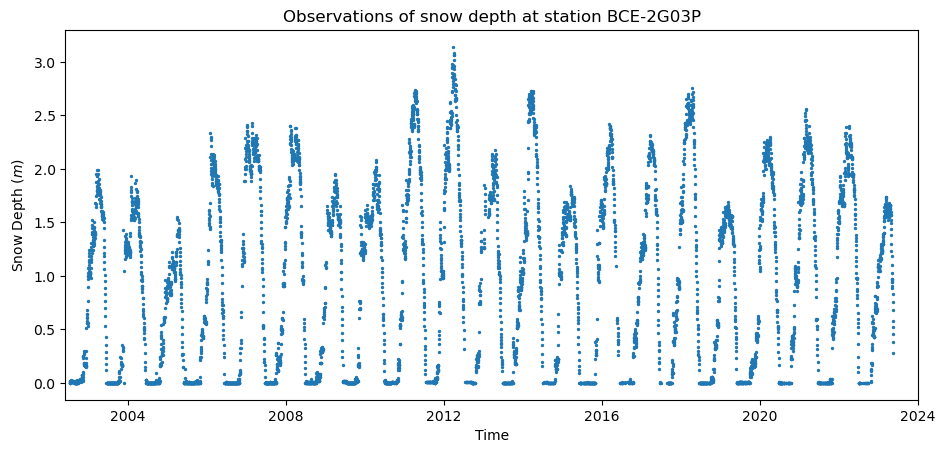

In [116]:
title = 'Observations of snow depth at station '+stn 
xaxis = 'Time'
yaxis = 'Snow Depth ($m$)'
create_time_series([reduced_Df], 'snd', [stn],  title, xaxis, yaxis, 
                   datetime(2002, 6, 1).date(), datetime(2024, 1, 1), False)

The maximum snow depth is 3.14 meters on March 21, 2012. The minimum snow depth is 0 meters when there is no snow, which is usually from late May to early November. The average snow depth is approximately 0.38 meters.

#### Plotting The Time Series of Snowpack Bulk Density Data For Station BCE-2G03P
Thirdly, we use the `create_time_series()` function to plot the snowpack bulk density data for Station BCE-2G03P.

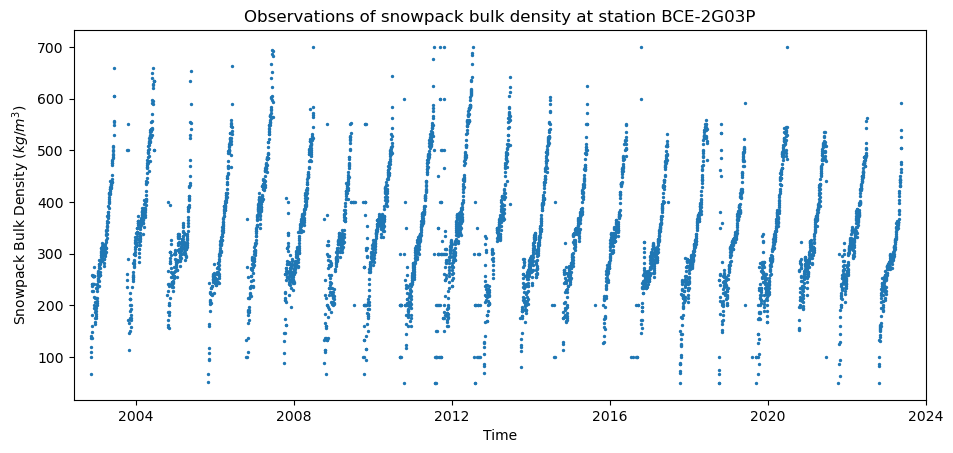

In [117]:
title = 'Observations of snowpack bulk density at station '+stn 
xaxis = 'Time'
yaxis = 'Snowpack Bulk Density ($kg/m^3$)'
create_time_series([reduced_Df], 'den', [stn], title, xaxis, yaxis, 
                   datetime(2002, 6, 1).date(), datetime(2024, 1, 1), False)

The maximum snowpack bulk density is 700 $kg/m^3$, which occurs a few times. The minimum snowpack bulk density is 50 $kg/m^3$, which occurs a few times if we exclude the NaN (Not a number) values from the dataset. The average snowpack bulk density is 100 $kg/m^3$.

## Visualizing CanSWE Data From Multiple Locations

#### Finding The Number of Stations in British Columbia

In [118]:
temp_df = pd.DataFrame()
temp_df['station_id'] = df['station_id']
temp_df['lon'] = df['lon']
temp_df['lat'] = df['lat']
temp_df['source'] = df['source']
temp_df.drop_duplicates(subset = None, keep = "first", inplace = True)

bc_df = temp_df.groupby('source')
bc_stn = bc_df.get_group("British Columbia Environment")['station_id']
bc_lon = bc_df.get_group("British Columbia Environment")['lon']
bc_lat = bc_df.get_group("British Columbia Environment")['lat']

print('Number of Stations in British Columbia: '+ str(len(bc_stn)))

Number of Stations in British Columbia: 531


Among the 531 stations in British Columbia, we have seen the evolution of snow water equivalent, snow depth and snowpack bulk density for station BCE-2G03P. In this next section of the tutorial, we will continue to work with this station, but we will also examine 2 nearby stations, which are stations BCE-2F05P and BCE-2F10P. We effectively found these stations by filtering the original dataframe to create a subset of the data that only contains stations located in British Columbia.

#### Introducing Stations BCE-2F05P and BCE-2F10P

In [119]:
df.loc[(df['station_id'] == 'BCE-2F05P')].iloc[[0], [0, 2, 3, 4, 6]]

,station_id,lat,lon,elevation,station_name
692364,BCE-2F05P,49.94467,-118.9497,1780.0,MISSION CREEK-PILLOW


In [120]:
df.loc[(df['station_id'] == 'BCE-2F10P')].iloc[[0], [0, 2, 3, 4, 6]]

,station_id,lat,lon,elevation,station_name
710706,BCE-2F10P,50.37136,-119.06211,1840.0,SILVER STAR MOUNTAIN


The official name of station BCE-2F05P is Mission Creek-Pillow. It has a latitude of 49.94467 (degrees North), a longitude of -118.9497 (degrees East), and an elevation of 1780 meters. <br>
The official name of station BCE-2F10P is Silver Star Mountain. It has a latitude of 50.37136 (degrees North), a longitude of -119.06211 (degrees East), and an elevation of 1840 meters.

#### Plotting The Geographical Location of Stations BCE-2G03P, BCE-2F05P and BCE-2F10P
Using our `create_map_plot()` function again, we will plot these 3 stations on one graph to illustrate where they are located and how close they are to one another.

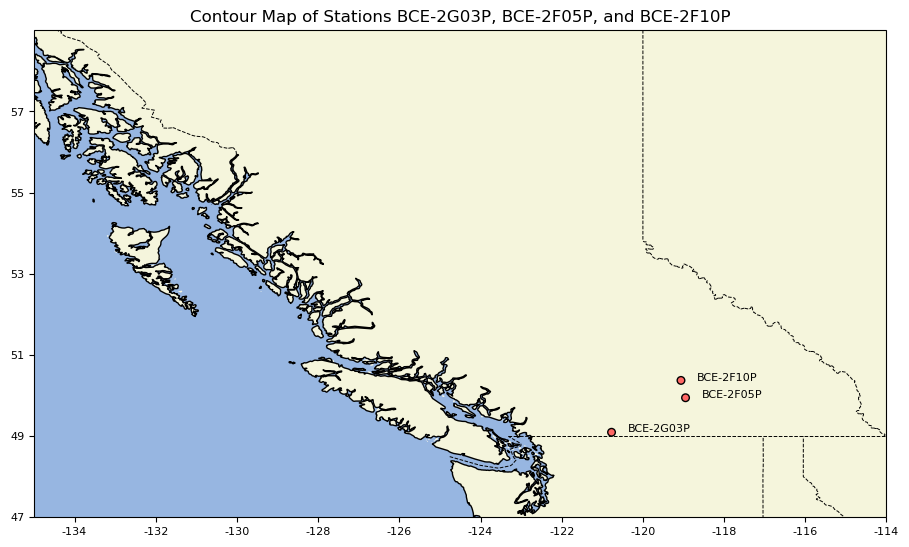

In [121]:
# Station BCE-2F05P
stn2 = 'BCE-2F05P'
latitude2 = 49.94467
longitude2 = -118.9497

# Station BCE-2F10P
stn3 = 'BCE-2F10P'
latitude3 = 50.37136
longitude3 = -119.06211

map = pd.DataFrame(columns = ['lon', 'lat', 'station_id', 'xlabel', 'ylabel'])
map.loc[0] = ({'lon': longitude, 'lat': latitude, 'station_id': stn, 'xlabel': longitude + 0.4, 'ylabel': latitude})
map.loc[1] = ({'lon': longitude2, 'lat': latitude2, 'station_id': stn2, 'xlabel': longitude2 + 0.4, 'ylabel': latitude2})
map.loc[2] = ({'lon': longitude3, 'lat': latitude3, 'station_id': stn3, 'xlabel': longitude3 + 0.4, 'ylabel': latitude3})
create_map_plot(map, (-135, -114, 47, 59), 2, 2, True, True, 'Contour Map of Stations '+stn+ ', '+stn2+', and '+stn3)

#### Extracting Data For Stations BCE-2F05P and BCE-2F10P into Separate Lists
In this section of the tutorial, we will compare the data that is found in stations BCE-2G03P, BCE-2F05P and BCE-2F10P. However, before this comparison, we first need to interate through the SWE Pandas dataframe to find where the data for stations BCE-2F05P and BCE-2F10P are located. Then, we could extract the snow water equivalence data for these 2 stations.

In [122]:
# Station BCE-2F05P
# Finding where the Station BCE-2F05P data is, and storing it in a dataframe
i2 = -1
count2 = 0
for index, row in df.iterrows():
    if row['station_id'] == 'BCE-2F05P':
        i2 = index
        break

for index, row in df.iterrows():
    if row['station_id'] == 'BCE-2F05P':
        count2 = count2 + 1

begin2 = i2
end2 = begin2 + count2 - 1
reduced_Df2 = df.loc[begin2:end2]

# Station BCE-2F10P
# Finding where the Station BCE-2F10P data is, and storing it in a dataframe
i3 = -1
count3 = 0
for index, row in df.iterrows():
    if row['station_id'] == 'BCE-2F10P':
        i3 = index
        break

for index, row in df.iterrows():
    if row['station_id'] == 'BCE-2F10P':
        count3 = count3 + 1

begin3 = i3
end3 = begin3 + count3 - 1
reduced_Df3 = df.loc[begin3:end3]

#### Plotting The Snow Water Equivalent of Stations BCE-2G03P, BCE-2F05P and BCE-2F10P
We use the `create_time_series()` function to plot the SWE data for stations BCE-2G03P, BCE-2F05P and BCE-2F10P.

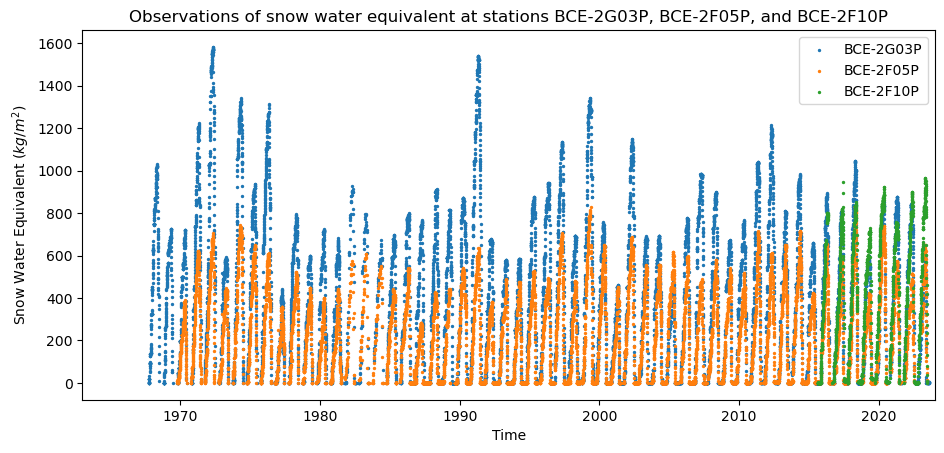

In [123]:
title = 'Observations of snow water equivalent at stations '+stn+', '+stn2+', and '+stn3
xaxis = 'Time'
yaxis = 'Snow Water Equivalent ($kg/m^2$)'
create_time_series([reduced_Df, reduced_Df2, reduced_Df3], 'snw', [stn, stn2, stn3],
                 title, xaxis, yaxis, datetime(1963, 1, 1).date(), datetime(2024, 1, 1), True)


#### Plotting a Condensed Time Series of Snow Water Equivalent For BCE-2F05P and BCE-2F10P

We can see from the above plot that the 3 time series all have variable lengths. Furthermore, they all have winter seasonal peaks because that is when we have snow. Let's "zoom in" to the time period with coverage from all three time series.

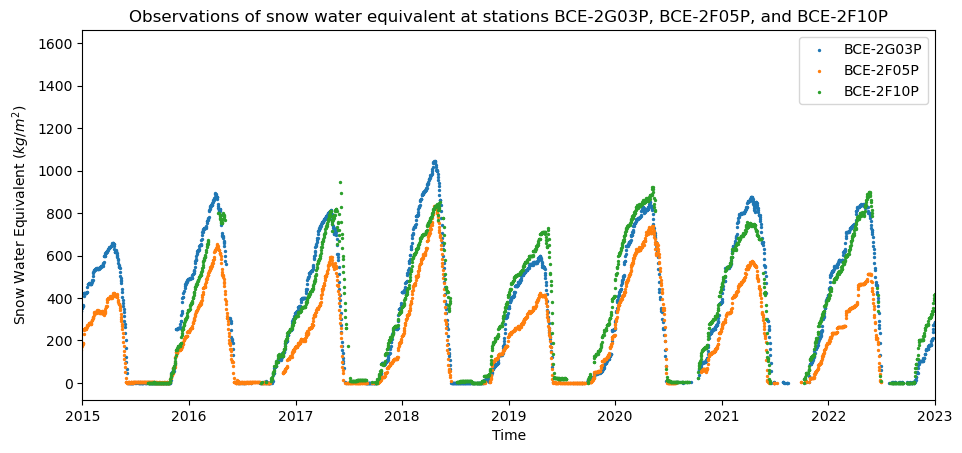

In [124]:
title = 'Observations of snow water equivalent at stations '+stn+', '+stn2+', and '+stn3
xaxis = 'Time'
yaxis = 'Snow Water Equivalent ($kg/m^2$)'
create_time_series([reduced_Df, reduced_Df2, reduced_Df3], 'snw', [stn, stn2, stn3],
                 title, xaxis, yaxis, datetime(2015, 1, 1).date(), datetime(2023, 1, 1).date(), True)

From the above graph, we can see that Station BCE-2F05P (in orange) has lower peaks compared to the other 2 stations (in green and blue). This means that the maximum snow water equivalent in this location is lower than the maximum snow water equivalent in the other 2 locations.

#### Finding a Station in British Columbia With a Snow Water Equivalent Measurement Code of 0
The 3 stations we have examined so far all have a snow water equivalent measurement code of 2, which means the data is sampled using a snow pillow or a snow scale. We also want to determine if different measurement codes  produce different snow water equivalent trends. As a result, we will find a station in British Columbia that has a measurement code of 0, which means that this data is sampled using a multi point manual snow survey.

#### Introducing Station BCE-2G03
One station in British Columbia with a measurement code of 0 is station BCE-2G03. The official name of station BCE-2G03 is Blackwall Peak. It has a latitude of 49.1 (degrees North) and a longitude of -120.76667 (degrees East). The elevation there is 1940 meters. In this section of the tutorial, we will work with 2 stations: BCE-2G03 and BCE-2G03P. The former one is the station we just introduced. The latter one is a station we have worked with previously (the one with the most entries).

#### Plotting The Geogphical Locations of BCE-2G03P and BCE-2G03
Using our `create_map_plot()` function again, we will plot these 2 stations on one graph to illustrate where they are located and how close they are to one another.

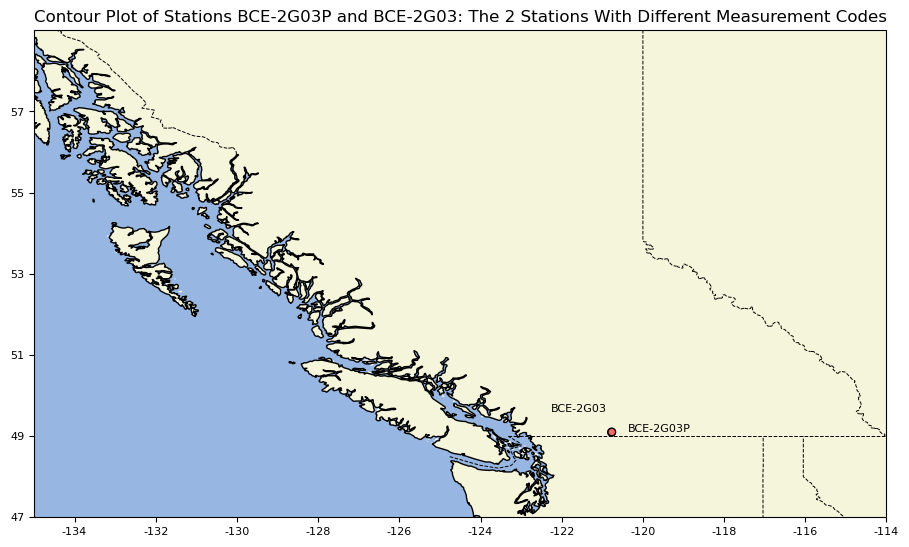

In [125]:
stn4 = 'BCE-2G03'

# Station BCE-2G03
latitude4 = 49.1
longitude4 = -120.76667

map = pd.DataFrame(columns = ['lon', 'lat', 'station_id', 'xlabel', 'ylabel'])
map.loc[0] = ({'lon': longitude, 'lat': latitude, 'station_id': stn, 'xlabel': longitude + 0.4, 'ylabel': latitude})
map.loc[1] = ({'lon': longitude4, 'lat': latitude4, 'station_id': stn4, 'xlabel': longitude4 - 1.5, 'ylabel': latitude4 + 0.5})
create_map_plot(map, (-135, -114, 47, 59), 2, 2, True, True, 'Contour Plot of Stations '+stn+' and '+ stn4+ ': The 2 Stations With Different Measurement Codes')


In the above contour plot, we only see one blue circle marker because station BCE-2G03P and BCE-2G03 have the exact same longitude and latitude coordinate. 

#### Extracting Data For Stations BCE-2G03 into Separate Lists
Before we compare the data for stations BCE-2G03 and BCE-2G03P, we first need to interate through the SWE Pandas dataframe to find where the data for Station BCE-2G03 is located. Then, we could extract the snow water equivalence data for this station.

In [126]:
# Station BCE-2G03
# Finding where the Station BCE-2G03 data is, and storing it in a dataframe
i4 = -1
count4 = 0
for index, row in df.iterrows():
    if row['station_id'] == stn4:
        i5 = index
        break

for index, row in df.iterrows():
    if row['station_id'] == stn4:
        count4 = count4 + 1

begin4 = i4
end4 = begin4 + count4 - 1
reduced_Df4 = df.loc[begin4:end4]

#### Plotting SWE Data For BCE-2G03 and BCE-2G03P

In the contour plot where we plotted the locations of stations BCE-2G03 and BCE-2G03P, we can see that they are extremely close to each other. As a result, we will take a closer look at how their snow water equivalent data differs.

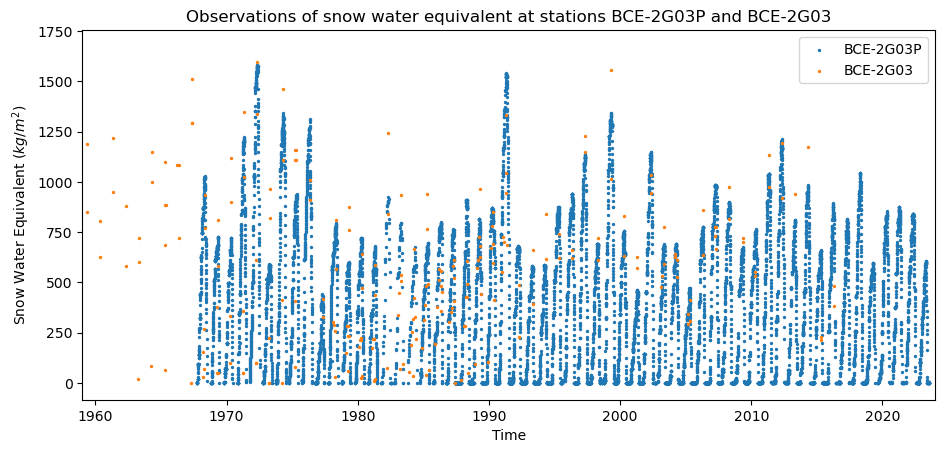

In [127]:
title = 'Observations of snow water equivalent at stations '+stn+' and '+stn4
xaxis = 'Time'
yaxis = 'Snow Water Equivalent ($kg/m^2$)'
create_time_series([reduced_Df, reduced_Df4], 'snw', [stn, stn4],
                 title, xaxis, yaxis, datetime(1959, 1, 1).date(), datetime(2024, 1, 1).date(), True)

From the above contour plot, the data in orange is sparse, with only a few measurements taken each season and with the measurements being mostly present before the 2000s. It is most likely the case that the data in orange, which was gathered using manual sampling methods, are starting to be discontinued in favor of the automatic measurement techniques used to record the data that we see in blue.

#### Plotting SWE Data For Station BCE-2G03P But Distinguishing Them Based on Quality Flags
Quality flags provides information on the reliability of data in this dataset. For station BCE-2G03P, most of the data is not flagged, which means that it should be reliable. However, there are flags for some data points which could mean the data is missing (M flag), the data is an estimate (E flag) or the data is even revised (R flag). We will now plot the data for station BCE-2G03P and distinguish the data points by their quality flags.

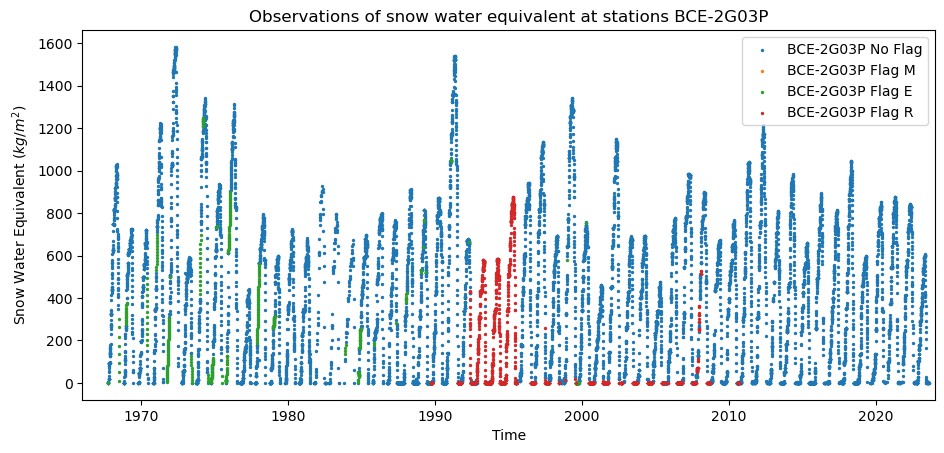

Number of Missing SWE Entries For BCE-2G03P: 780


In [128]:
df2 = reduced_Df.groupby('data_flag_snw')

e_flag_df = pd.DataFrame()
e_flag_df['time'] = df2.get_group("b'E'")['time']
e_flag_df['snw'] = df2.get_group("b'E'")['snw']
e_flag_df['station_id'] = stn+" Flag E"

r_flag_df = pd.DataFrame()
r_flag_df['time'] = df2.get_group("b'R'")['time']
r_flag_df['snw'] = df2.get_group("b'R'")['snw']
r_flag_df['station_id'] = stn+" Flag R"

m_flag_df = pd.DataFrame()
m_flag_df['time'] = df2.get_group("b'M'")['time']
m_flag_df['snw'] = df2.get_group("b'M'")['snw']
m_flag_df['station_id'] = stn+" Flag M"

no_flag_df = pd.DataFrame()
no_flag_df['time'] = df2.get_group("b''")['time']
no_flag_df['snw'] = df2.get_group("b''")['snw']
no_flag_df['station_id'] = stn+" No Flag"

title = 'Observations of snow water equivalent at stations '+stn
xaxis = 'Time'
yaxis = 'Snow Water Equivalent ($kg/m^2$)'
create_time_series([no_flag_df, m_flag_df, e_flag_df, r_flag_df], 'snw', [stn+ ' No Flag', stn+ ' Flag M', stn+ ' Flag E', stn+' Flag R'],
                   title, xaxis, yaxis, datetime(1966, 1, 1).date(), datetime(2024, 1, 1).date(), True)

print('Number of Missing SWE Entries For '+stn+ ': '+str(m_flag_df.size))


From the graph above, we can tell that the estimated data (in green) was present during the 1970s and 1980s. Furthermore, the revised data (in red) was predominately present during the 1990s, but there were also some entries during the 2000s and 2010s. Finally, the missing data is not plotted but the first entry of missing data actually was in 2002 and we have 780 missing entries. This graph illustrates that most data is of the highest quality because it is not flagged, but it also illustrates that we are obtaining more accurate and precise data as the years go on. Since the 1990s, we do not need to estimate data anymore because we have the tools and technologies for revised data if there were any sampling barriers during the normal sampling period. Nonetheless, if we could not sample well outside of the normal sampling period, we left the data out so that our data is as reliable as they can be.

#### Plotting SWE Data From All Stations In British Columbia

 In this final section of the tutorial, we'll make a map plot showing all stations in British Columbia where the colour of the station markers tell us about the maximum SWE observed at that location for the year 2023. Using a red-blue colour scale, stations with a smaller max SWE will have reddish markers and stations with a larger max SWE will be blueish.

In [129]:
max_df = pd.DataFrame(columns = ['station_id', 'lon', 'lat', 'snw'])
max_stn = ''
max_count = 0
max_longitude = 0
max_latitude = 0
max_index = 0
for index, row in df.iterrows():
    if row['source'] == 'British Columbia Environment' and datetime.strptime(row['time'], '%Y-%m-%d').year == 2023:
        if max_stn == '':
            max_stn = row['station_id']
            max_count = row['snw']
            max_longitude = row['lon']
            max_latitude = row['lat']
        elif max_stn == row['station_id']:
            if row['snw'] > max_count:
                max_count = row['snw']
                max_longitude = row['lon']
                max_latitude = row['lat']
        else:
            max_df.loc[max_index] = ({'station_id': max_stn, 'lon': max_longitude, 'lat': max_latitude, 'snw': max_count})
            max_stn = row['station_id']
            max_count = row['snw']
            max_longitude = row['lon']
            max_latitude = row['lat']
            max_index = max_index + 1

max_df = max_df.sort_values(by = 'snw')

map = pd.DataFrame()
map['lon'] = max_df['lon']
map['lat'] = max_df['lat']
map['station_id'] = np.repeat('', map['lon'].size)
map['xlabel'] = np.repeat(np.nan, map['lon'].size)
map['ylabel'] = np.repeat(np.nan, map['lat'].size)
map['snw'] = max_df['snw']

create_map_plot(map, (-138, -114, 48, 60), 2, 2, True, False, 'Contour Map of The Maximum SWE For all Stations In British Columbia During 2023')

From the above contour plot, we can see that most sites have a maximum SWE of less than 1000 in 2023, which can be seen through the abundance of reddish markers.